# 01 — Generate Hexagonal Grid

Subdivide the Kona Coffee Belt region into equal-area hexagonal cells.

Each cell becomes one sample in the feature matrix.

- Grid resolution: **250 m** (cell area ≈ 54,000 m²)  
- Projection: **EPSG:32604** (UTM Zone 4N — covers west Big Island)
- Output: `../data/polygons/kona_grid.pkl`

Cells are labelled:
- `label = 1` if the cell centroid falls inside a known coffee-farm polygon
- `label = 0` otherwise (background — inside region, not labelled as coffee)

In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon, MultiPolygon, Point
import os

UTM_CRS  = 'EPSG:32604'   # UTM Zone 4N — west Big Island
MIN_AREA = 54_000          # m² target hex cell area (≈250 m circumradius)
DATA_DIR = '../data/polygons'

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
# Load region and farm polygons
region = gpd.read_file(os.path.join(DATA_DIR, 'kona_region.geojson')).to_crs(UTM_CRS)
farms  = gpd.read_file(os.path.join(DATA_DIR, 'kona_coffee_farms.geojson')).to_crs(UTM_CRS)

print('Region CRS:', region.crs)
print('Bounds (m):', region.total_bounds)

Region CRS: EPSG:32604
Bounds (m): [ 813937.46060352 2109016.2186907   874600.02898821 2187503.32741194]


In [3]:
def make_hex(cx, cy, r):
    """Flat-top hexagon with circumradius r."""
    angles = np.deg2rad([0, 60, 120, 180, 240, 300])
    return Polygon([(cx + r * np.cos(a), cy + r * np.sin(a)) for a in angles])


def clean_geom(g, min_area):
    if g.is_empty:
        return None
    g = g.buffer(0)
    if g.is_empty:
        return None
    if isinstance(g, MultiPolygon):
        g = max(g.geoms, key=lambda x: x.area)
    if g.area < min_area:
        return None
    return g


def subdivide_hexagonal(poly, min_area_m2):
    """Tile a polygon with flat-top hexagons of ~min_area_m2 area."""
    # A = (3√3 / 2) * r²  →  r = sqrt(2A / 3√3)
    r     = np.sqrt((2 * min_area_m2) / (3 * np.sqrt(3)))
    horiz = 1.5 * r
    vert  = np.sqrt(3) * r

    minx, miny, maxx, maxy = poly.bounds
    hexes, row = [], 0
    y = miny
    while y <= maxy + vert:
        x_start = minx + (0.75 * r if row % 2 else 0)
        x = x_start
        while x <= maxx + horiz:
            h      = make_hex(x, y, r)
            clipped = poly.intersection(h)
            geom   = clean_geom(clipped, min_area_m2 * 0.25)
            if geom is not None:
                hexes.append(geom)
            x += horiz
        y += vert
        row += 1
    return hexes


In [4]:
# Tile the region
region_poly = region.unary_union
hexes = subdivide_hexagonal(region_poly, MIN_AREA)
print(f'Generated {len(hexes):,} hexagonal cells')

grid = gpd.GeoDataFrame({'geometry': hexes}, crs=UTM_CRS)
grid['plot_id'] = grid.index
grid['centroid'] = grid.geometry.centroid
grid['area_m2'] = grid.geometry.area
grid['area_ha'] = grid['area_m2'] / 10_000
grid.head(3)

Generated 10,211 hexagonal cells


,geometry,plot_id,centroid,area_m2,area_ha
0,"POLYGON ((858344.069 2109050.901, 858169.522 2...",0,POINT (858286.022 2109099.702),13685.571462,1.368557
1,"POLYGON ((858542.068 2109023.611, 858360.159 2...",1,POINT (858493.835 2109080.578),22569.813787,2.256981
2,"POLYGON ((858741.803 2109016.219, 858561.521 2...",2,POINT (858702.387 2109073.642),26055.352940,2.605535


In [5]:
# Label cells: 1 = inside a coffee-farm polygon, 0 = background
farms_union = farms.unary_union

grid['label'] = grid['centroid'].apply(
    lambda pt: 1 if farms_union.contains(pt) else 0
)

print(f'Positive (coffee) cells: {grid["label"].sum():,}')
print(f'Background cells:        {(grid["label"]==0).sum():,}')

Positive (coffee) cells: 471
Background cells:        9,740


Saved kona_grid.pkl


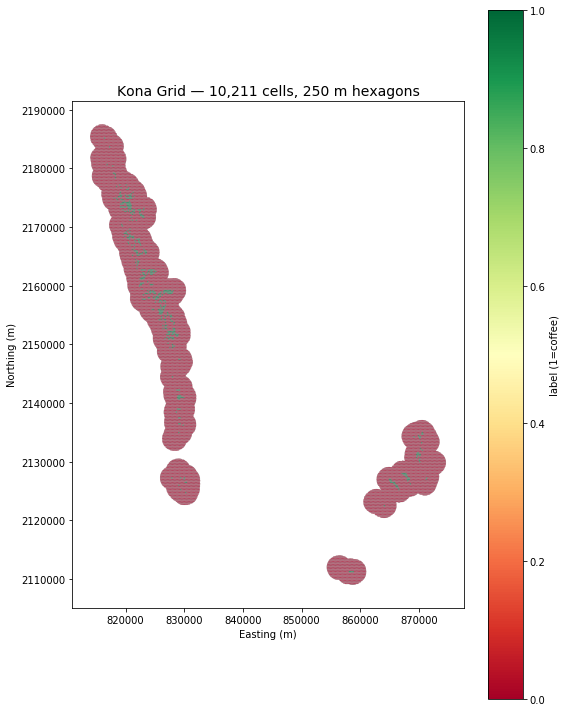

In [6]:
# Save
grid_latlon = grid.drop(columns='centroid').to_crs('EPSG:4326')
grid_latlon.to_pickle(os.path.join(DATA_DIR, 'kona_grid.pkl'))
print('Saved kona_grid.pkl')

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))
grid.plot(ax=ax, column='label', cmap='RdYlGn', alpha=0.7, edgecolor='grey',
          linewidth=0.2, legend=True, legend_kwds={'label': 'label (1=coffee)'})
ax.set_title(f'Kona Grid — {len(grid):,} cells, 250 m hexagons', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.savefig('../img/01_grid.png', dpi=150)
plt.show()